# WordStructure Statistiques — évolution de S2 à S8

In [244]:
import re,codecs,yaml
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def ding():
    os.system('afplay /System/Library/Sounds/Submarine.aiff')

%store -r ordStemCells

In [79]:
sns.set_style("whitegrid")

In [80]:
repFiles="/Users/gilles/sDrive/Recherche/Boye/HDR/Data/vlexique2.0.3/WordStructure/"
statistiquesFile="vlexique2-Statistiques.yaml"
fStatistiques=repFiles+statistiquesFile

In [81]:
with open(fStatistiques,"r") as inFile:
     brutStats=yaml.safe_load(inFile)
# brutStats

In [82]:
m=re.match(r"^([\w-]+?)(\d+)(-(Train|Test)(\d+))?(-StemSpace)?","Direct-S8-omp")
if m:
    print(m.group(0))

Direct-S8


# Tableaux

In [83]:
stats={}
for k,v in brutStats.items():
    m=re.match(r"^([\w-]+?)(\d+)(-(Train|Test)(\d+))?(-StemSpace)?",k)
    if m:
        # print(m.group(1),m.group(2),m.group(3),m.group(4),m.group(5),m.group(6))
        inputType=m.group(1)
        quantile=m.group(2)
        if m.group(3):
            sampleType=m.group(4).strip("-")
            numSample=m.group(5)
        else:
            sampleType="Freq"
            numSample=m.group(2)
        if m.group(6):
            runType=m.group(6).strip("-")
        else:
            runType="Swim2"
        stats[(inputType,quantile,sampleType,numSample,runType)]=v
# stats

In [84]:
dict_of_df = {k: pd.DataFrame(v) for k,v in stats.items()}
df = pd.concat(dict_of_df, axis=1).T
df.index.names=["inputType","quantile","sampleType","numSample","runType","checkType"]
df["couverture"]=df.nbCorrect/(df.nbCorrect+df.nbDifferent+df.nbMissing)*100
# df.style.format("{:.1f}%",subset=["precision","rappel","couverture"]).format("{:.0f}",subset=["nbConnu","nbCorrect","nbDifferent","nbMissing"])

In [85]:
def maxCol(column):    

    hlMax='background-color: springgreen;'
    hlOver='background-color: paleturquoise;'
    hlUnder='background-color: lightsalmon;'
    hlMin='background-color: violet;'
    default = ""

    cMax=column.max()
    cMin=column.min()
    cMean=column.mean()
    cUpper=(cMax+cMean)/2
    cLower=(cMin+cMean)/2

    # must return one string per cell in this column
    return [hlMax if v==cMax else hlMin if v==cMin else hlOver if v>cUpper else hlUnder if v<cLower else default for v in column]

df.style.apply(maxCol, subset=['precision', 'rappel',"couverture"], axis=0).format("{:.1f}%",subset=["precision","rappel","couverture"]).format("{:.0f}",subset=["nbConnu","nbCorrect","nbDifferent","nbMissing"])

In [86]:
dfMinMax=df.groupby(["checkType","runType","sampleType","inputType","quantile"])[["precision","rappel","couverture"]].agg(["min","max","mean","std"])
dfMinMax.fillna(value=0).style.format("{:.1f}%").apply(maxCol, subset=[('precision',"mean"), ('rappel',"mean"),("couverture","mean")], axis=0)

In [87]:
dfResults=df.groupby(["checkType","runType","sampleType","inputType","quantile"])[["precision","rappel"]].mean()
dfResults["F1"]=2*dfResults.precision*dfResults.rappel/(dfResults.precision+dfResults.rappel)
dfResults.style.apply(maxCol, subset=['precision', 'rappel',"F1"], axis=0).format("{:.1f}%")
# dfResults#.plot(kind="bar",figsize=(20,3))

# Graphes évolution

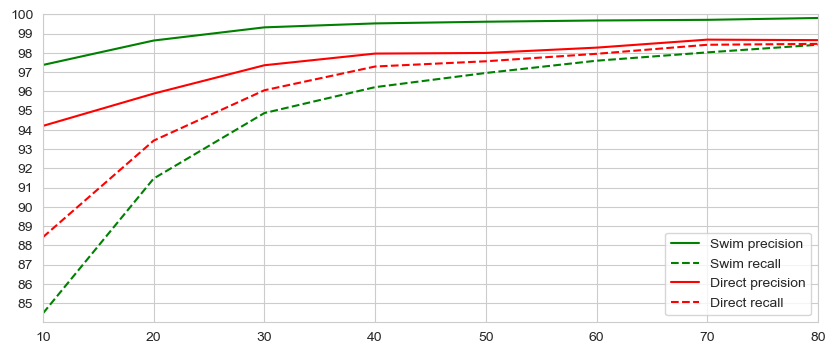

In [105]:
selS=(df.index.get_level_values(0)=="S")&(df.index.get_level_values(4)=='StemSpace')&(df.index.get_level_values(5)=='gold')
labels=[10,20,30,40,50,60,70,80,100]
dfS=df[selS].loc[:,["precision","couverture"]].sort_index(ascending=False)
dfS.index=labels
selD=(df.index.get_level_values(0)=="Direct-S")&(df.index.get_level_values(5)=='gold')
dfD=df[selD].loc[:,["precision","couverture"]].sort_index(ascending=False)
dfD.index=labels[:8]
dfComp=pd.concat([dfS,dfD],axis=1)
dfComp.columns=["Swim precision","Swim recall","Direct precision","Direct recall"]
axComp=dfComp.plot(figsize=(10,4),style=["-","--","-","--"],color=["green","green","red","red"])
axComp.set_ylim(84,100)
axComp.set_xlim(10,80)
axComp.set_yticks(range(85,101))

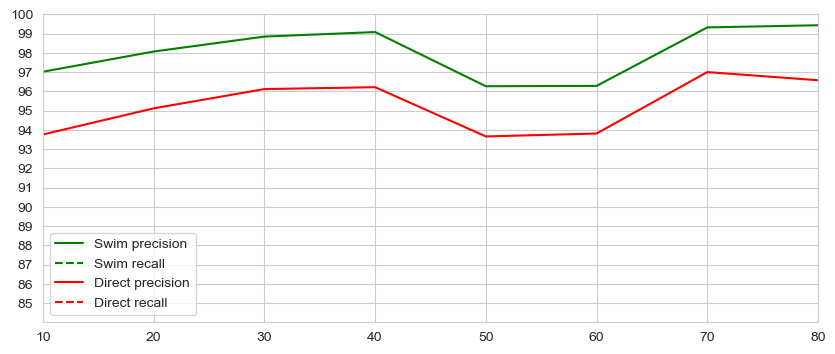

In [106]:
selS=(df.index.get_level_values(0)=="S")&(df.index.get_level_values(4)=='StemSpace')&(df.index.get_level_values(5)=='platinum')
labels=[10,20,30,40,50,60,70,80,100]
dfS=df[selS].loc[:,["precision","couverture"]].sort_index(ascending=False)
dfS.index=labels
selD=(df.index.get_level_values(0)=="Direct-S")&(df.index.get_level_values(5)=='platinum')
dfD=df[selD].loc[:,["precision","couverture"]].sort_index(ascending=False)
dfD.index=labels[:8]
dfComp=pd.concat([dfS,dfD],axis=1)
dfComp.columns=["Swim precision","Swim recall","Direct precision","Direct recall"]
axComp=dfComp.plot(figsize=(10,4),style=["-","--","-","--"],color=["green","green","red","red"])
axComp.set_ylim(84,100)
axComp.set_xlim(10,80)
axComp.set_yticks(range(85,101))